In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

#  Load dataset
air_quality_data = pd.read_csv("./AirQualityUCI.csv", sep=";", decimal=",")

air_quality_data

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
air_quality_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), str(2)
memory usage: 1.2 MB


In [16]:
# Clean trailing empty columns/rows
air_quality_data = air_quality_data.dropna(how='all').dropna(how='all', axis=1)

air_quality_data.tail()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
9352,04/04/2005,10.00.00,3.1,1314.0,-200.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568
9353,04/04/2005,11.00.00,2.4,1163.0,-200.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119
9354,04/04/2005,12.00.00,2.4,1142.0,-200.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406
9355,04/04/2005,13.00.00,2.1,1003.0,-200.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139
9356,04/04/2005,14.00.00,2.2,1071.0,-200.0,11.9,1047.0,265.0,654.0,168.0,1129.0,816.0,28.5,13.1,0.5028


In [17]:
# Aggregate the date and time columns into a single datetime column
air_quality_data['Datetime'] = pd.to_datetime(air_quality_data['Date'] + ' ' + air_quality_data['Time'],
                                              format='%d/%m/%Y %H.%M.%S')

air_quality_data = air_quality_data.set_index('Datetime')
air_quality_data.drop(columns={"Date","Time"}, inplace=True)

air_quality_data.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [18]:
# Count and percentage of missing values
air_quality_data = air_quality_data.replace(-200, np.nan)

missing = pd.DataFrame({
    'count': (air_quality_data).isna().sum(),
    'percent': (air_quality_data.isna().mean() * 100).round(1)
}).sort_values('count', ascending=False)

missing

,count,percent
NMHC(GT),8443,90.2
CO(GT),1683,18.0
NO2(GT),1642,17.5
NOx(GT),1639,17.5
PT08.S1(CO),366,3.9
PT08.S2(NMHC),366,3.9
C6H6(GT),366,3.9
PT08.S3(NOx),366,3.9
PT08.S4(NO2),366,3.9
PT08.S5(O3),366,3.9


In [19]:
# Duplicates
ts_dups = air_quality_data.index.duplicated()
print("Duplicate timestamps:", ts_dups.sum())

full_dups = air_quality_data.reset_index().duplicated()
print("Complete row duplicates (incl. timestamp):", full_dups.sum())

Duplicate timestamps: 0
Complete row duplicates (incl. timestamp): 0


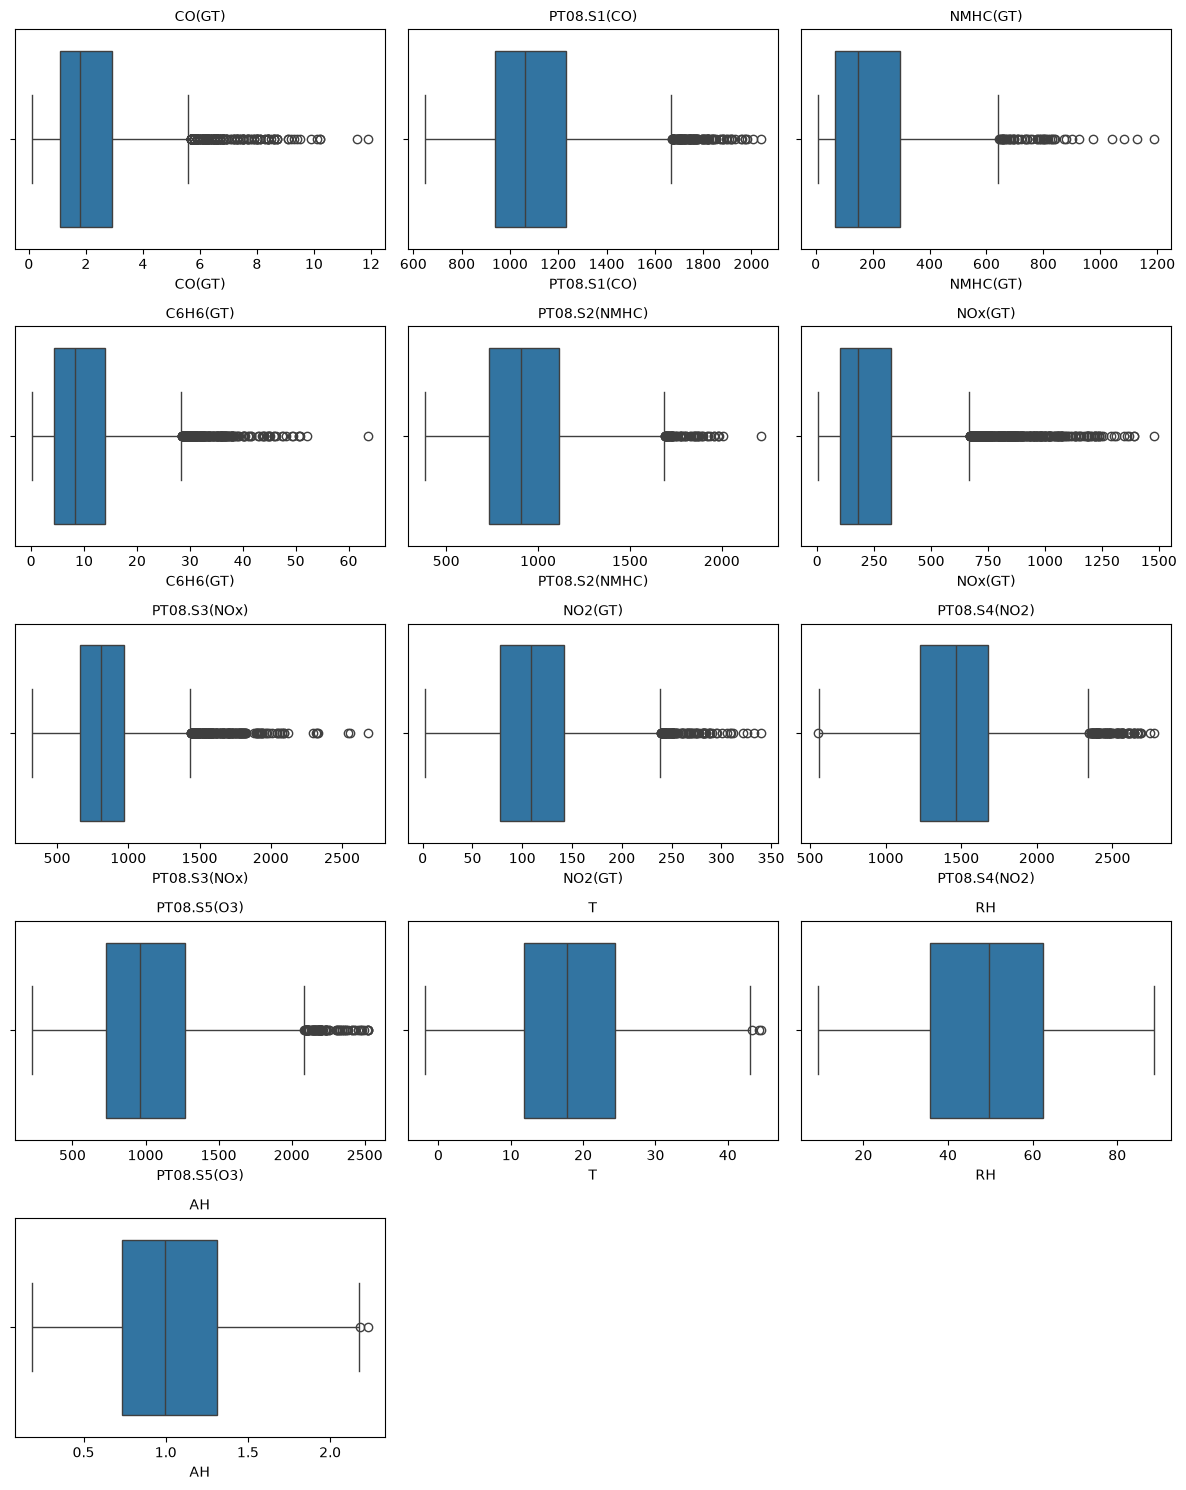

,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
NOx(GT),98.00,326.00,228.00,-244.00,668.00,435,4.65
PT08.S3(NOx),658.00,969.50,311.50,190.75,1436.75,241,2.58
C6H6(GT),4.40,14.00,9.60,-10.00,28.40,228,2.44
CO(GT),1.10,2.90,1.80,-1.60,5.60,215,2.30
PT08.S1(CO),937.00,1231.00,294.00,496.00,1672.00,118,1.26
NO2(GT),78.00,142.00,64.00,-18.00,238.00,107,1.14
PT08.S4(NO2),1227.00,1674.00,447.00,556.50,2344.50,97,1.04
PT08.S5(O3),731.50,1273.50,542.00,-81.50,2086.50,93,0.99
PT08.S2(NMHC),734.50,1116.00,381.50,162.25,1688.25,65,0.69
NMHC(GT),67.00,297.00,230.00,-278.00,642.00,55,0.59


In [20]:
numeric_cols = air_quality_data.select_dtypes(include='number').columns

# Boxplots arranged in a grid
n_cols = 3
n_rows = -(-len(numeric_cols) // n_cols)  # ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=air_quality_data[col], ax=ax)
    ax.set_title(col, fontsize=10)

# Hide any unused subplots
for ax in axes[len(numeric_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

outlier_summary = {}
for col in numeric_cols:
    q1, q3 = air_quality_data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((air_quality_data[col] < lower) | (air_quality_data[col] > upper)).sum()

    outlier_summary[col] = {
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': n_outliers,
        'outlier_pct': round(n_outliers / air_quality_data.shape[0] * 100, 2)
    }

outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index')
outlier_df = outlier_df.sort_values('outlier_count', ascending=False)
outlier_df

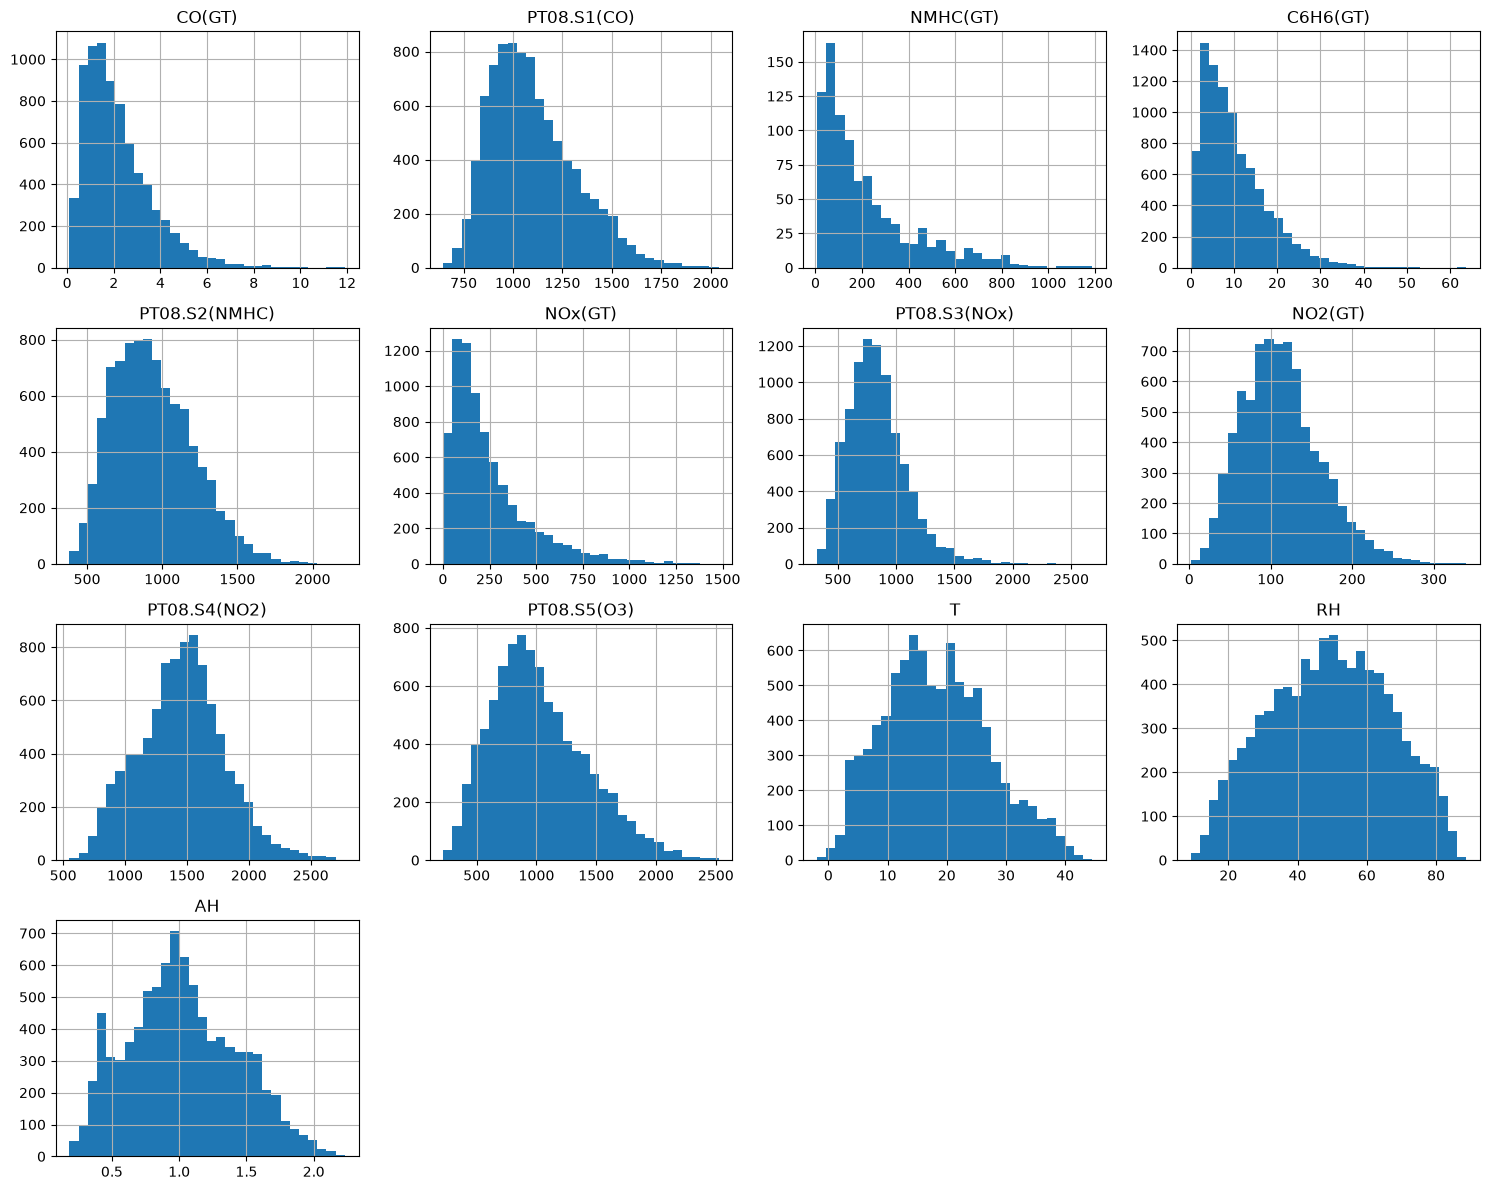

In [21]:
# Feature distribution
air_quality_data[numeric_cols].hist(bins=30, figsize=(15, 12))
plt.tight_layout()
plt.show()

In [22]:
# Skewness 
skewness = air_quality_data[numeric_cols].skew().sort_values(ascending=False)
skewness_df = skewness.reset_index()
skewness_df.columns = ['variable', 'skewness']
skewness_df

,variable,skewness
0,NOx(GT),1.715781
1,NMHC(GT),1.557017
2,CO(GT),1.369753
3,C6H6(GT),1.361532
4,PT08.S3(NOx),1.101729
5,PT08.S1(CO),0.755907
6,PT08.S5(O3),0.627864
7,NO2(GT),0.621714
8,PT08.S2(NMHC),0.561566
9,T,0.309357


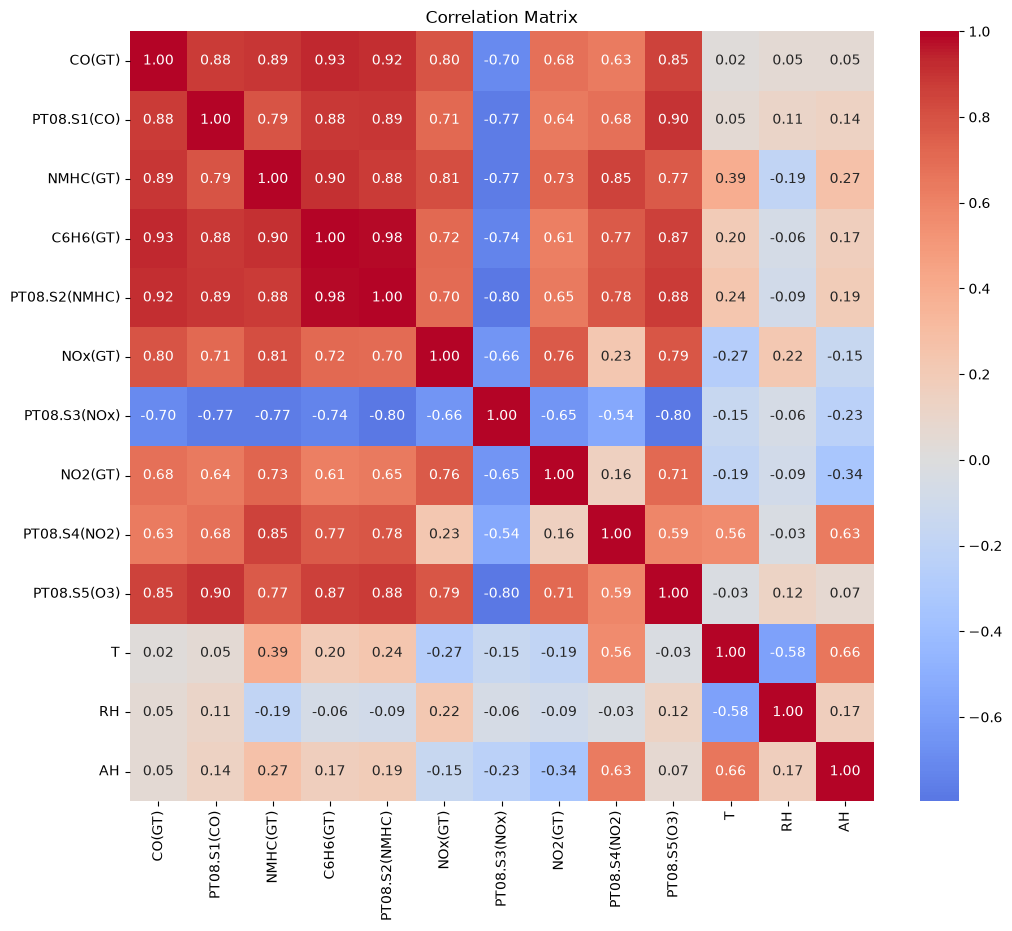

,Variable 1,Variable 2,Correlation
0,PT08.S2(NMHC),C6H6(GT),0.982
1,C6H6(GT),CO(GT),0.931
2,PT08.S2(NMHC),CO(GT),0.916
3,C6H6(GT),NMHC(GT),0.903
4,PT08.S5(O3),PT08.S1(CO),0.899
5,PT08.S2(NMHC),PT08.S1(CO),0.893
6,NMHC(GT),CO(GT),0.890
7,C6H6(GT),PT08.S1(CO),0.884
8,PT08.S5(O3),PT08.S2(NMHC),0.881
9,PT08.S1(CO),CO(GT),0.879


In [23]:
corr_matrix = air_quality_data[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Mask to keep only the upper triangle (excluding diagonal), so each pair appears once
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
corr_pairs = corr_matrix.where(mask).unstack().dropna()
corr_pairs = corr_pairs.sort_values(key=abs, ascending=False)

corr_table = corr_pairs.head(10).reset_index()
corr_table.columns = ['Variable 1', 'Variable 2', 'Correlation']
corr_table['Correlation'] = corr_table['Correlation'].round(3)

corr_table


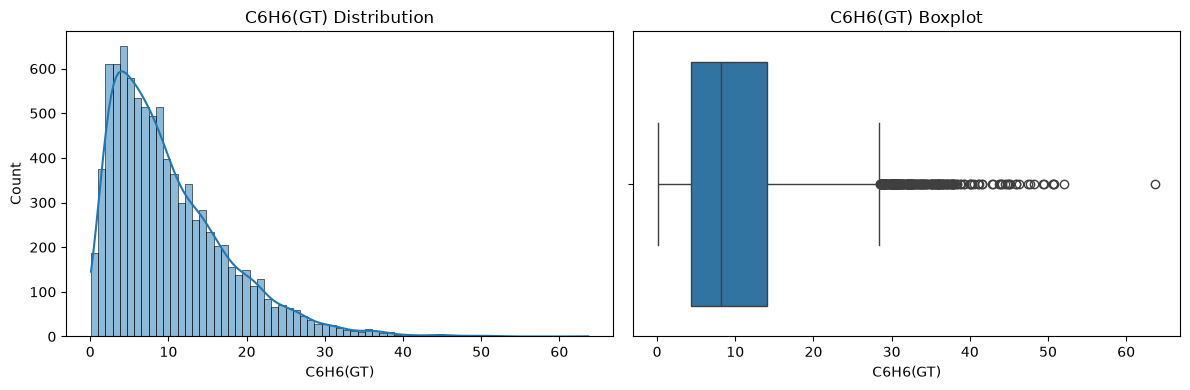

Target mean: 10.08 μg/m³
Target median: 8.20 μg/m³
Target std: 7.45
Target min: 0.10, max: 63.70
Target skewness: 1.36


In [24]:
# Target variable analysis
target = air_quality_data['C6H6(GT)'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(target, kde=True, ax=axes[0])
axes[0].set_title('C6H6(GT) Distribution')
sns.boxplot(x=target, ax=axes[1])
axes[1].set_title('C6H6(GT) Boxplot')
plt.tight_layout() 
plt.show()

print(f"Target mean: {target.mean():.2f} μg/m³")
print(f"Target median: {target.median():.2f} μg/m³")
print(f"Target std: {target.std():.2f}")
print(f"Target min: {target.min():.2f}, max: {target.max():.2f}")
print(f"Target skewness: {target.skew():.2f}")